# Marketing Campaign Project By Hanouf Almogri

## Intro

### This study evaluates the effectiveness of three marketing promotions in a multi-arm experimental setting. Weekly sales data were collected across multiple store locations over four weeks. The analysis examines both overall promotion performance and temporal dynamics, including potential interaction effects between promotion and time.

## Goal
### Decide which marketing campaign works best.

In [1]:
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import levene, f_oneway, kruskal, ttest_ind

sns.set_style('whitegrid')

In [2]:

df = pd.read_csv('/Users/alhanoufalmogri/Downloads/WA_Marketing-Campaign.csv')

df.head()

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


## Data Validation and Inspectaion

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MarketID          548 non-null    int64  
 1   MarketSize        548 non-null    object 
 2   LocationID        548 non-null    int64  
 3   AgeOfStore        548 non-null    int64  
 4   Promotion         548 non-null    int64  
 5   week              548 non-null    int64  
 6   SalesInThousands  548 non-null    float64
dtypes: float64(1), int64(5), object(1)
memory usage: 30.1+ KB


In [4]:
df.duplicated().sum()

np.int64(0)

#### at first we must understand the data and its structure so we will check the info of the data and check for any missing values or duplicated values. and according to the results we have no-nulls, no duplicates


#### now we had to validate the data:

In [5]:
# Each location should have only one promotion
promo_check = df.groupby("LocationID")["Promotion"].nunique()
print("Locations with multiple promotions:", (promo_check > 1).sum())


Locations with multiple promotions: 0


In [6]:
# Each location should have 4 weeks
week_check = df.groupby("LocationID")["week"].nunique()
print(week_check.value_counts())

week
4    137
Name: count, dtype: int64


#### the data is valid 

## EDA

In [7]:
df.groupby("Promotion")["SalesInThousands"].agg(["mean", "std", "count"])
df.groupby(["Promotion", "week"])["SalesInThousands"].mean().unstack()

week,1,2,3,4
Promotion,,,,
1,58.244419,56.929535,58.774884,58.447209
2,47.730213,47.582553,47.722128,46.282766
3,55.776170,55.949149,54.377872,55.354681


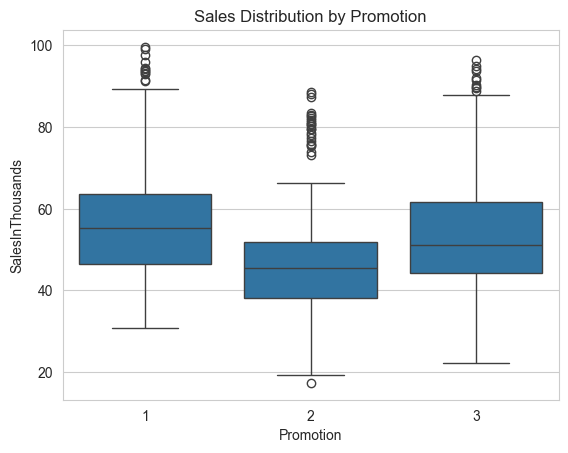

In [8]:
sns.boxplot(data=df, x="Promotion", y="SalesInThousands")
plt.title("Sales Distribution by Promotion")
plt.show()

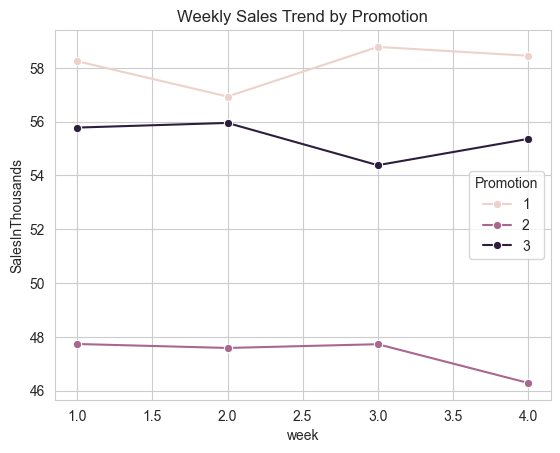

In [9]:
weekly_summary = df.groupby(['week', 'Promotion'])['SalesInThousands'].mean().reset_index()

sns.lineplot(data=weekly_summary, x='week', y='SalesInThousands', hue='Promotion', marker='o')
plt.title('Weekly Sales Trend by Promotion')
plt.show()

In [10]:
location_sales = df.groupby(['LocationID', 'Promotion'], as_index=False)['SalesInThousands'].mean()
location_sales.rename(columns={"SalesInThousands": "AvgSales"}, inplace=True)
#create location_sales to make it easier to analyze 
location_sales.head()

,LocationID,Promotion,AvgSales
0,1,3,34.4200
1,2,2,29.5450
2,3,1,40.6800
3,4,2,33.7075
4,5,2,29.0025


## Assumption Testing

In [13]:
from scipy.stats import shapiro, levene # for normality and homogeneity of variance test

for p in location_sales['Promotion'].unique():
    stat, pval = shapiro(location_sales[location_sales['Promotion']==p]['AvgSales'])
    print(f"Promotion {p} normality p-value:", round(pval, 5))

groups = [location_sales[location_sales['Promotion']==p]['AvgSales'] for p in sorted(location_sales['Promotion'].unique())]
print("Levene test:", round(levene(*groups).pvalue, 5))

Promotion 3 normality p-value: 0.00013
Promotion 2 normality p-value: 2e-05
Promotion 1 normality p-value: 0.00016
Levene test: 0.62717


#### the results show that the data fail the normality and and homogeneity of variance assumptions this mean using any parametric test (such as ANOVA or t-test) is not appropriate but we will ignore this and use it since we didnt discuss the non-parametric tests

## Hypothesis

- **H0:** The mean sales are the same for Promotion 1, Promotion 2, and Promotion 3.
- **H1:** At least one promotion has a different mean sales.

## One-Way ANOVA 

In [14]:
from scipy.stats import f_oneway

anova_stat, anova_p = f_oneway(*groups)
print("ANOVA p-value:", round(anova_p, 5))

ANOVA p-value: 0.00368


## Tukey Post Hoc

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=location_sales['AvgSales'],
    groups=location_sales['Promotion'],
    alpha=0.05
)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     1      2 -10.7696  0.004 -18.5951  -2.944   True
     1      3  -2.7345 0.6862 -10.5601   5.091  False
     2      3   8.0351 0.0371   0.3854 15.6847   True
-----------------------------------------------------


## Conclusion
### 1- Promotion 1 shows the highest average sales, but the difference between Promotion 1 and Promotion 3 is not significant, while Promotion 2 has significantly lower average sales than them.

### 2- Weekly trends indicate that all 3 promotions kind of remain consistent throughout the whole month.
